# Logging and Monitoring Deployed ML Models

Deploying a model is not the end of the work — it is the beginning. Once your model is serving real traffic, you need to know:
- Is it responding? (availability)
- How fast is it responding? (latency)
- Are predictions drifting from what the training distribution would suggest? (model health)

This notebook simulates a production logging and monitoring setup locally. All patterns apply directly to CloudWatch (AWS), Cloud Monitoring (GCP), and Azure Monitor.

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 5, lesson 09 "09. Model Monitoring and Performance Tracking" — the same health questions, answered here from structured logs a cloud monitor can query, with request IDs so a single bad prediction can be traced back to its call.


## 📰 March 2020: Instacart's availability model went stale in a week

Instacart's item-availability model predicts whether a product a customer ordered will actually be on the shelf when a shopper arrives. In Instacart's own engineering write-up of the pandemic — *Building an Essential Service During a Pandemic*, a Q&A with CTO Mark Schaaf, tech.instacart.com, 21 May 2020 — the company reported that **at the beginning of March 2020 it saw "nearly a 30% drop in ordered items being found"** as stockpiling emptied shelves of toilet paper, flour, eggs and sanitiser.

Nothing about the model had changed. The shelves had. Instacart's fix was a monitoring-and-retraining fix: they **doubled how often the availability model ran, to every 60 minutes**, and cut its lookback window **from 30 days to one week, and in places three days** — because a month of history had become a description of a world that no longer existed.

Now notice what an infrastructure dashboard would have shown during those weeks. CPU: normal. Memory: normal. Error rate: zero. Latency: unchanged. The service was *perfectly healthy* while the thing it predicted had moved underneath it. **Availability monitoring and model monitoring are different disciplines**, and this notebook is where they meet: the same structured log line has to carry both the latency your SRE cares about and the confidence your data scientist cares about.

**What goes wrong without this lesson.** Log unstructured text and you cannot query it: "what was p99 latency for this model version between 14:00 and 15:00" becomes a grep. Log only the prediction and you cannot replay the request that produced a bad answer. Log nothing about confidence and you will find out about Instacart's problem from customers rather than from a chart.

## Learning Objectives

By the end of this notebook you will be able to:
1. Emit structured JSON logs from a prediction function
2. Simulate a realistic stream of prediction requests with varying latency
3. Compute p50, p95, p99 latency and explain the difference
4. Plot latency over time and a prediction distribution histogram
5. Explain how confidence score distribution can proxy for model accuracy monitoring

## Section 1 — Structured Logging

Plain-text logs are hard to query. Structured logs emit each record as JSON so tools like CloudWatch Insights, BigQuery, or Elasticsearch can filter by field.

Every prediction log record should include:
- **timestamp** — when did the request arrive?
- **request_id** — unique ID to trace one request across services
- **input_features** — what did the caller send? (needed to replay and debug)
- **prediction** and **confidence** — what did the model return?
- **latency_ms** — how long did inference take?
- **model_version** — which model produced this output?

In [1]:
# WHAT: build a structured (JSON-lines) logger and a log_prediction() helper.
# WHY: cloud log systems (CloudWatch, Stackdriver) parse JSON automatically —
# one line per event with named fields is what makes logs QUERYABLE, not just readable.
import logging
import json
import uuid
import time
import pathlib
from datetime import datetime, timezone

LOG_FILE = pathlib.Path('/tmp/ml_predictions.jsonl')
LOG_FILE.unlink(missing_ok=True)  # start fresh

# Instead of free text, format every record as one JSON object per line.
class JSONFormatter(logging.Formatter):
    """Emit each log record as a single JSON line."""
    def format(self, record):
        log_obj = {
            'timestamp': datetime.fromtimestamp(record.created, tz=timezone.utc).isoformat(),
            'level': record.levelname,
            'logger': record.name,
        }
        # Merge any extra fields passed to the logger
        if hasattr(record, 'extra'):
            log_obj.update(record.extra)
        else:
            log_obj['message'] = record.getMessage()
        return json.dumps(log_obj)

# Two destinations: the .jsonl file (for analysis) and the console (for humans).
# Set up logger
logger = logging.getLogger('ml_api')
logger.setLevel(logging.INFO)
logger.handlers.clear()

file_handler = logging.FileHandler(LOG_FILE)
file_handler.setFormatter(JSONFormatter())
logger.addHandler(file_handler)

console_handler = logging.StreamHandler()
console_handler.setFormatter(JSONFormatter())
logger.addHandler(console_handler)

# One call captures everything an incident review needs: input, output,
# confidence, latency, version, and a request id to trace it by.
def log_prediction(features, prediction, confidence, latency_ms, model_version='1.0.0', error=None):
    """Log a prediction event as a structured JSON record."""
    record = logging.LogRecord(
        name='ml_api', level=logging.INFO,
        pathname='', lineno=0, msg='', args=(), exc_info=None
    )
    record.extra = {
        'event': 'prediction',
        'request_id': str(uuid.uuid4())[:8],
        'model_version': model_version,
        'input_features': features,
        'prediction': prediction,
        'confidence': confidence,
        'latency_ms': latency_ms,
        'error': error,
    }
    logger.handle(record)

# Log a single prediction to see what the record looks like
log_prediction(
    features=[5.1, 3.5, 1.4, 0.2],
    prediction='setosa',
    confidence=0.97,
    latency_ms=12.3,
)

{"timestamp": "2026-08-29T19:28:55.601415+00:00", "level": "INFO", "logger": "ml_api", "event": "prediction", "request_id": "64a948ad", "model_version": "1.0.0", "input_features": [5.1, 3.5, 1.4, 0.2], "prediction": "setosa", "confidence": 0.97, "latency_ms": 12.3, "error": null}


## Section 2 — Simulate 500 Prediction Requests

We train a model and run 500 simulated requests through it, logging every result. Latency is simulated with random noise to mimic real network and compute variability.

In [2]:
# WHAT: train the model, then simulate 500 logged requests with realistic latency.
# WHY: monitoring lessons need volume — 500 structured records give the analysis
# cells below something real to aggregate.
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train model
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train)
clf = RandomForestClassifier(n_estimators=100, random_state=42).fit(scaler.transform(X_train), y_train)

print(f"Model ready. Test accuracy: {clf.score(scaler.transform(X_test), y_test):.2%}")

# Reset logging for the bulk simulation. The file handler from the setup cell
# still holds the original file descriptor, so unlinking the path out from under
# it would send writes to a deleted inode (and LOG_FILE.stat() would then fail).
# Detach the old handlers, start a fresh file, and skip the console handler so we
# don't print 500 JSON lines.
for _h in list(logger.handlers):
    _h.close()
    logger.removeHandler(_h)
LOG_FILE.unlink(missing_ok=True)
_bulk_handler = logging.FileHandler(LOG_FILE)
_bulk_handler.setFormatter(JSONFormatter())
logger.addHandler(_bulk_handler)

# Simulated traffic: slight feature noise plus an occasional latency spike.
N_REQUESTS = 500
rng = np.random.default_rng(seed=42)

# Simulate requests: mostly from the test set, some random noise
for i in range(N_REQUESTS):
    # Sample a random test point (or add slight noise)
    base_features = X_test[i % len(X_test)]
    noisy_features = base_features + rng.normal(0, 0.05, size=base_features.shape)
    noisy_features = np.clip(noisy_features, X.min(axis=0), X.max(axis=0))

    # Simulate inference time: mostly 10-30ms, occasional spikes
    latency = rng.exponential(15) + rng.choice([0, 100], p=[0.97, 0.03])
    latency = round(float(np.clip(latency, 1, 500)), 2)

    start = time.perf_counter()
    features_s = scaler.transform(noisy_features.reshape(1, -1))
    pred = int(clf.predict(features_s)[0])
    conf = float(clf.predict_proba(features_s)[0].max())
    _ = time.perf_counter() - start  # actual inference time

    log_prediction(
        features=noisy_features.round(3).tolist(),
        prediction=iris.target_names[pred],
        confidence=round(conf, 3),
        latency_ms=latency,
        model_version='1.0.0',
    )

print(f"Simulated {N_REQUESTS} requests. Log written to {LOG_FILE}")
print(f"Log file size: {LOG_FILE.stat().st_size / 1024:.1f} KB")

Model ready. Test accuracy: 100.00%


Simulated 500 requests. Log written to /tmp/ml_predictions.jsonl
Log file size: 141.8 KB


## Section 3 — Parse Logs and Compute Metrics

In [3]:
# WHAT: read the .jsonl log back and compute latency percentiles, class mix, and
# confidence stats — monitoring from logs alone.
# WHY: this is exactly what a dashboard does; doing it once by hand teaches what
# p95 and prediction-distribution panels actually aggregate.
import json
from collections import Counter

# Load all log records
records = []
with open(LOG_FILE) as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                pass

# Filter to prediction events only
pred_records = [r for r in records if r.get('event') == 'prediction']
latencies = np.array([r['latency_ms'] for r in pred_records])
predictions = [r['prediction'] for r in pred_records]
confidences = np.array([r['confidence'] for r in pred_records])
error_count = sum(1 for r in pred_records if r.get('error'))

# Percentiles, not means: the p95/p99 tail is what users complain about.
# Latency percentiles
p50 = np.percentile(latencies, 50)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)

print(f"Total predictions : {len(pred_records)}")
print(f"Error count       : {error_count} ({error_count/len(pred_records)*100:.1f}%)")
print()
print("Latency statistics (ms):")
print(f"  Mean : {latencies.mean():.1f}")
print(f"  p50  : {p50:.1f}  (50% of requests faster than this)")
print(f"  p95  : {p95:.1f}  (95% of requests faster than this)")
print(f"  p99  : {p99:.1f}  (99% of requests faster than this)")
print(f"  Max  : {latencies.max():.1f}")
print()
print("Prediction distribution:")
for label, count in sorted(Counter(predictions).items()):
    pct = count / len(predictions) * 100
    print(f"  {label:12s}: {count:4d} ({pct:.1f}%)")
print()
print(f"Mean confidence   : {confidences.mean():.3f}")
print(f"Min confidence    : {confidences.min():.3f}")

Total predictions : 500
Error count       : 0 (0.0%)

Latency statistics (ms):
  Mean : 18.2
  p50  : 10.8  (50% of requests faster than this)
  p95  : 56.5  (95% of requests faster than this)
  p99  : 110.0  (99% of requests faster than this)
  Max  : 169.7

Prediction distribution:
  setosa      :  166 (33.2%)
  versicolor  :  155 (31.0%)
  virginica   :  179 (35.8%)

Mean confidence   : 0.968
Min confidence    : 0.510


## Section 4 — Visualize Latency and Prediction Distribution

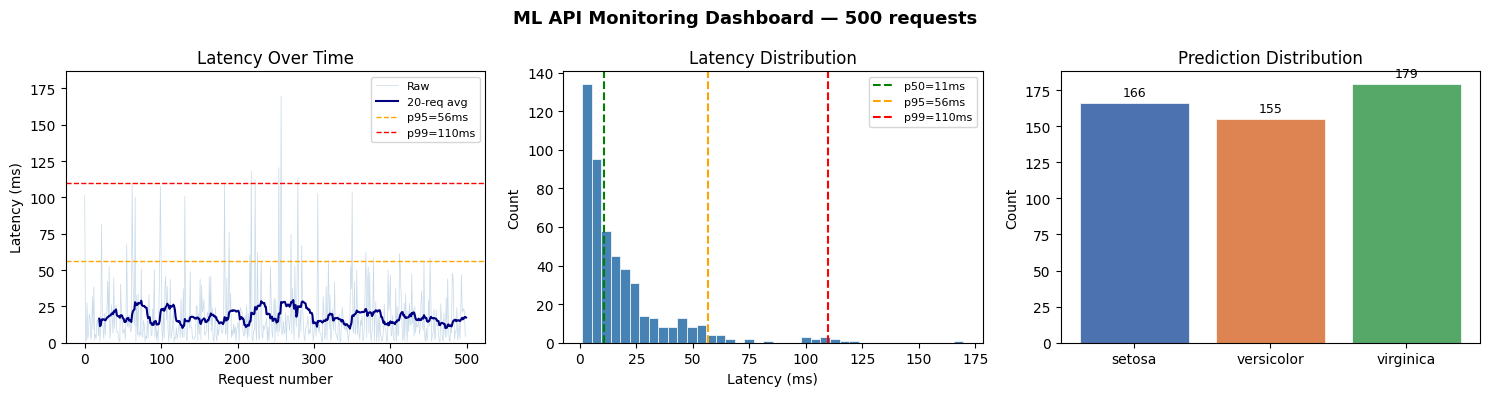

Dashboard saved to /tmp/monitoring_dashboard.png


In [4]:
# Build the 3-panel monitoring dashboard: latency over time, latency
# distribution, and prediction-class distribution. Rendered inline (no 'Agg'
# backend switch) so the charts are visible in the notebook itself.
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Latency over time (rolling average)
ax = axes[0]
window = 20
rolling_avg = np.convolve(latencies, np.ones(window)/window, mode='valid')
ax.plot(latencies, alpha=0.3, color='steelblue', linewidth=0.5, label='Raw')
ax.plot(range(window-1, len(latencies)), rolling_avg, color='navy', linewidth=1.5, label=f'{window}-req avg')
ax.axhline(p95, color='orange', linestyle='--', linewidth=1, label=f'p95={p95:.0f}ms')
ax.axhline(p99, color='red', linestyle='--', linewidth=1, label=f'p99={p99:.0f}ms')
ax.set_title('Latency Over Time')
ax.set_xlabel('Request number')
ax.set_ylabel('Latency (ms)')
ax.legend(fontsize=8)
ax.set_ylim(0, min(latencies.max() * 1.1, 300))

# Plot 2: Latency distribution
ax = axes[1]
ax.hist(latencies, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(p50, color='green', linestyle='--', label=f'p50={p50:.0f}ms')
ax.axvline(p95, color='orange', linestyle='--', label=f'p95={p95:.0f}ms')
ax.axvline(p99, color='red', linestyle='--', label=f'p99={p99:.0f}ms')
ax.set_title('Latency Distribution')
ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

# Plot 3: Prediction distribution
ax = axes[2]
pred_counts = Counter(predictions)
labels = sorted(pred_counts.keys())
counts = [pred_counts[l] for l in labels]
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(labels, counts, color=colors[:len(labels)], edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(count), ha='center', va='bottom', fontsize=9)
ax.set_title('Prediction Distribution')
ax.set_ylabel('Count')

plt.suptitle(f'ML API Monitoring Dashboard — {len(pred_records)} requests', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/monitoring_dashboard.png', dpi=100, bbox_inches='tight')
plt.show()
print('Dashboard saved to /tmp/monitoring_dashboard.png')

**🔍 Read the figure.** *Left:* individual request latency is spiky (the pale line) while the 20-request rolling average (navy) is stable at roughly 15–25 ms and never comes near the p95 or p99 lines — those are set by the handful of spikes in the pale trace, not by the typical request. *Centre:* the same numbers as a distribution. Most of the mass sits under 30 ms; the p99 at **110 ms** is out in a thin right tail that the histogram makes visible and the mean of **18.2 ms** hides completely. This is why an SLA written on the mean is a promise about nobody in particular. *Right:* the three classes come out roughly balanced — 166 / 155 / 179, near a third each — which is what a healthy prediction mix looks like for this model and this input stream. Sections 6 and 7 are about what it means when that third panel stops looking like this.

### One more thing the dashboard will happily get wrong

Every panel above was computed from the whole 500-record log at once. A real dashboard does not do that: it bins requests into time buckets, computes a percentile inside each bucket, and then — when you widen the time range — **averages those bucket percentiles together**. The cell below does exactly that to the same logged latencies and compares the answer with the truth.

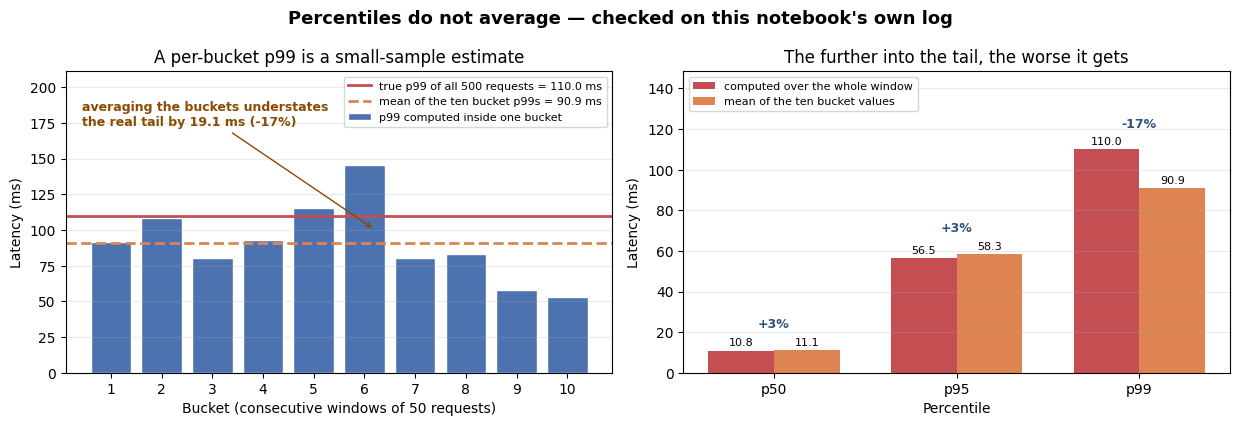

500 logged latencies, split into 10 buckets of 50
  bucket p99s (ms): [91.6, 108.7, 80.1, 93.1, 115.1, 145.6, 80.0, 83.4, 58.1, 53.1]
  spread across buckets: 53.1 to 145.6 ms
  p50: whole window   10.8 ms | mean of buckets   11.1 ms | error +3.0%
  p95: whole window   56.5 ms | mean of buckets   58.3 ms | error +3.3%
  p99: whole window  110.0 ms | mean of buckets   90.9 ms | error -17.3%


In [5]:
# WHAT: bucket the same 500 logged latencies the way a dashboard bins them, take a
# percentile inside each bucket, average those, and compare with the percentile of
# the whole window.
# WHY: "the mean of four hourly p99s is not the daily p99" is a warning in the
# Where-this-breaks list. It is also arithmetic we can check on the log we just
# wrote, and the size of the error is the part that surprises people.
import numpy as np
import matplotlib.pyplot as plt

N_BUCKETS = 10                                    # ten consecutive windows of 50 requests
buckets = latencies.reshape(N_BUCKETS, -1)        # what a dashboard would call its time bins

bucket_p99 = np.percentile(buckets, 99, axis=1)
mean_of_bucket_p99 = bucket_p99.mean()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))

# --- Left: the ten bucket p99s against the one true p99 ---------------------
ax = axes[0]
xs = np.arange(1, N_BUCKETS + 1)
ax.bar(xs, bucket_p99, color='#4C72B0', edgecolor='white',
       label='p99 computed inside one bucket')
ax.axhline(p99, color='#C44E52', lw=2,
           label=f'true p99 of all {len(latencies)} requests = {p99:.1f} ms')
ax.axhline(mean_of_bucket_p99, color='#DD8452', ls='--', lw=2,
           label=f'mean of the ten bucket p99s = {mean_of_bucket_p99:.1f} ms')
ax.annotate(f'averaging the buckets understates\nthe real tail by {p99 - mean_of_bucket_p99:.1f} ms '
            f'({(mean_of_bucket_p99 / p99 - 1):+.0%})',
            xy=(N_BUCKETS * 0.62, (p99 + mean_of_bucket_p99) / 2),
            xytext=(0.03, 0.82), textcoords='axes fraction',   # clear of the bars
            fontsize=9, color='#8a4a00', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#8a4a00'))
ax.set_xticks(xs)
ax.set_xlabel(f'Bucket (consecutive windows of {buckets.shape[1]} requests)')
ax.set_ylabel('Latency (ms)')
ax.set_title('A per-bucket p99 is a small-sample estimate')
ax.set_ylim(0, max(bucket_p99.max(), p99) * 1.45)
ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.25, axis='y')

# --- Right: the error grows with the percentile -----------------------------
ax = axes[1]
levels = [50, 95, 99]
true_vals = [float(np.percentile(latencies, q)) for q in levels]
avg_vals = [float(np.percentile(buckets, q, axis=1).mean()) for q in levels]
x = np.arange(len(levels)); w = 0.36
b1 = ax.bar(x - w / 2, true_vals, w, color='#C44E52', label='computed over the whole window')
b2 = ax.bar(x + w / 2, avg_vals, w, color='#DD8452', label='mean of the ten bucket values')
ax.bar_label(b1, fmt='%.1f', fontsize=8, padding=2)
ax.bar_label(b2, fmt='%.1f', fontsize=8, padding=2)
# Absolute offset, not a multiple: a 1.16x offset lands on top of the value
# labels when the bars are short (p50).
for xi, t, a in zip(x, true_vals, avg_vals):
    ax.text(xi, max(t, a) + max(true_vals) * 0.10, f'{(a / t - 1):+.0%}', ha='center',
            fontsize=9, fontweight='bold', color='#31527d')
ax.set_xticks(x); ax.set_xticklabels([f'p{q}' for q in levels])
ax.set_xlabel('Percentile')
ax.set_ylabel('Latency (ms)')
ax.set_title('The further into the tail, the worse it gets')
ax.set_ylim(0, max(true_vals) * 1.35)
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.25, axis='y')

fig.suptitle('Percentiles do not average — checked on this notebook\'s own log',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"{len(latencies)} logged latencies, split into {N_BUCKETS} buckets of {buckets.shape[1]}")
print(f"  bucket p99s (ms): {np.round(bucket_p99, 1).tolist()}")
print(f"  spread across buckets: {bucket_p99.min():.1f} to {bucket_p99.max():.1f} ms")
for q, t, a in zip(levels, true_vals, avg_vals):
    print(f"  p{q}: whole window {t:6.1f} ms | mean of buckets {a:6.1f} ms | error {(a / t - 1):+.1%}")


**🔍 Read the figure.** *Left:* each blue bar is the p99 of one bucket of 50 requests, and they disagree wildly with each other — the printed spread runs from about 53 ms to about 146 ms for the *same* service in the *same* five hundred requests, because a p99 taken over 50 samples is the second-largest value in a small sample and nothing more. The solid red line is the honest answer computed over all 500 requests (**110.0 ms**); the orange dashed line is what you get by averaging the ten buckets (**90.9 ms**). Averaging **understates the tail by about 17%** — and it does so silently, on a chart that looks completely normal.

*Right:* the same comparison at three percentiles, each pair labelled with its error. At **p50 and p95 the two bars agree to within 3%** — the median of a 50-request bucket really is a fair estimate of the median, and the p95 bars are close enough to be indistinguishable by eye. **The p99 pair is the one that breaks, by 17%**, and it is also the one that ends up in an SLA. The deeper into the tail a percentile reaches, the fewer samples in each bucket actually determine it. The rule to carry away: **compute percentiles from the raw distribution over the window you care about**, and treat any dashboard that lets you average them across buckets or across instances as a trap. Discuss question 1 asks which single number you would publish — this figure is about whether the number you publish is even the number you think you measured.

## 💬 Discuss

The percentile table is the experiment here: **mean 18.2 ms, p50 10.8 ms, p95 56.5 ms, p99 110.0 ms, max 169.7 ms.** The mean is closer to the median than to anything a slow user experiences.

1. If you had to publish exactly one latency number in a service-level agreement, which of those five would you choose, and what behaviour does that choice encourage in the team that has to meet it? (Consider what optimising for the mean would let you get away with.)
2. Every record logs `input_features`. That is what makes replay and drift analysis possible — and it also means feature values are now sitting in a log store. For a Saudi hospital deployment under the PDPL rules from notebook 01, is that log a data-protection problem? What would you change, and what capability would you lose?
3. Instacart's model degraded with no change in latency or error rate. Of the signals this notebook computes, which one would have moved first — and how much lead time would it really have bought over waiting for labels?

## Section 5 — Cloud Monitoring Overview

The patterns above run locally, but cloud platforms offer managed equivalents:

**AWS CloudWatch**
- Your application emits JSON logs to CloudWatch Logs
- CloudWatch Insights lets you query logs with SQL-like syntax:
  ```
  fields @timestamp, latency_ms, prediction
  | filter event = 'prediction'
  | stats pct(latency_ms, 99) as p99 by bin(5m)
  ```
- CloudWatch Alarms trigger when a metric exceeds a threshold (e.g., p99 > 500ms for 5 minutes)

**GCP Cloud Monitoring + Cloud Logging**
- Structured logs flow to Cloud Logging automatically from Cloud Run / GKE
- Log-based metrics convert log field values into Monitoring time series
- Equivalent query in Cloud Logging:
  ```
  resource.type="cloud_run_revision"
  jsonPayload.event="prediction"
  jsonPayload.latency_ms > 200
  ```

**Azure Monitor + Log Analytics**
- Logs go to a Log Analytics workspace
- Query with KQL (Kusto Query Language):
  ```kql
  customEvents
  | where name == "prediction"
  | summarize p99=percentile(todouble(customDimensions.latency_ms), 99) by bin(timestamp, 5m)
  ```

The JSON structure you log locally is the same structure these platforms index and query.

## Section 6 — Model Accuracy Monitoring Without Ground Truth

The hard problem: after deployment, you receive inputs but often do not have ground-truth labels to evaluate accuracy. You cannot compute accuracy directly.

**Proxy signals that indicate model degradation:**
1. **Confidence score distribution** — if the model's confidence drops, it is seeing unfamiliar inputs
2. **Prediction distribution shift** — if 90% of predictions suddenly become class A, something changed
3. **Input feature distribution** — if input values drift outside the training range, the model extrapolates

In [6]:
# WHAT: compare confidence distributions from a healthy and a degraded period
# using the two-sample Kolmogorov-Smirnov test.
# WHY: eyeballing histograms does not scale — the KS test gives a p-value an
# automated alert can act on every hour.
import numpy as np
from scipy import stats

# Simulate a "healthy" period and a "degraded" period
rng = np.random.default_rng(42)

# Healthy: confidence scores from real iris-like distribution
healthy_confidences = rng.beta(9, 1, size=200)  # high confidence, centered near 0.9

# Degraded: confidence drops as model sees out-of-distribution inputs
degraded_confidences = rng.beta(3, 3, size=200)  # much more uncertain

# Kolmogorov-Smirnov test: detects distributional shift
ks_stat, ks_pvalue = stats.ks_2samp(healthy_confidences, degraded_confidences)

print("Confidence Score Distribution Comparison:")
print(f"  Healthy period   — mean={healthy_confidences.mean():.3f}, std={healthy_confidences.std():.3f}")
print(f"  Degraded period  — mean={degraded_confidences.mean():.3f}, std={degraded_confidences.std():.3f}")
print()
print("Kolmogorov-Smirnov drift test:")
print(f"  KS statistic : {ks_stat:.3f}  (0 = identical, 1 = completely different)")
print(f"  p-value      : {ks_pvalue:.2e}")
print(f"  Drift detected: {'YES — investigate the model' if ks_pvalue < 0.05 else 'No significant drift'}")
print()
print("In production: run this test every hour/day comparing the last N predictions")
print("to a reference window from a known-good period.")

Confidence Score Distribution Comparison:
  Healthy period   — mean=0.905, std=0.081
  Degraded period  — mean=0.494, std=0.197

Kolmogorov-Smirnov drift test:
  KS statistic : 0.840  (0 = identical, 1 = completely different)
  p-value      : 3.81e-72
  Drift detected: YES — investigate the model

In production: run this test every hour/day comparing the last N predictions
to a reference window from a known-good period.


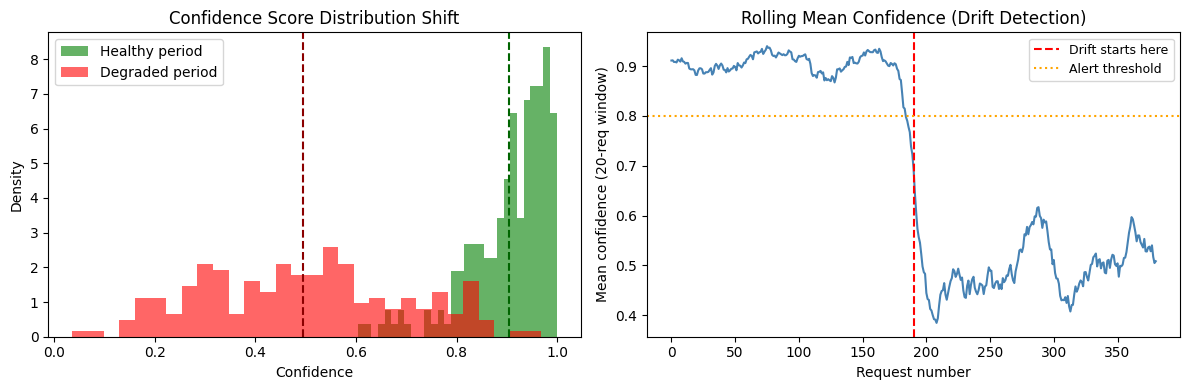

Drift detection chart saved to /tmp/drift_detection.png


In [7]:
# WHAT: visualize the drift — overlaid confidence histograms plus a rolling mean
# with an alert threshold line.
# WHY: the left panel shows WHAT changed (the distribution), the right shows
# WHEN it changed — the two questions every on-call engineer asks first.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confidence distribution comparison
ax = axes[0]
ax.hist(healthy_confidences, bins=30, alpha=0.6, color='green', label='Healthy period', density=True)
ax.hist(degraded_confidences, bins=30, alpha=0.6, color='red', label='Degraded period', density=True)
ax.axvline(healthy_confidences.mean(), color='darkgreen', linestyle='--', linewidth=1.5)
ax.axvline(degraded_confidences.mean(), color='darkred', linestyle='--', linewidth=1.5)
ax.set_title('Confidence Score Distribution Shift')
ax.set_xlabel('Confidence')
ax.set_ylabel('Density')
ax.legend()

# Rolling mean confidence over time (simulated)
# Rolling 20-request mean: the moment the curve crosses the threshold is the alert.
ax = axes[1]
all_conf = np.concatenate([healthy_confidences, degraded_confidences])
rolling_conf = np.convolve(all_conf, np.ones(20)/20, mode='valid')
t = range(len(rolling_conf))
ax.plot(t, rolling_conf, color='steelblue', linewidth=1.5)
ax.axvline(len(healthy_confidences) - 10, color='red', linestyle='--', label='Drift starts here')
ax.axhline(0.8, color='orange', linestyle=':', label='Alert threshold')
ax.set_title('Rolling Mean Confidence (Drift Detection)')
ax.set_xlabel('Request number')
ax.set_ylabel('Mean confidence (20-req window)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/drift_detection.png', dpi=100, bbox_inches='tight')
plt.show()
print('Drift detection chart saved to /tmp/drift_detection.png')

**🔍 Read the figure.** *Left:* two confidence distributions that barely overlap — the healthy window piles up between 0.8 and 1.0, the degraded window spreads right across the middle with its mean at 0.494. That separation is what the KS statistic of **0.840** measures; the p-value near **3.8e-72** says two samples this different essentially never come from the same distribution. *Right:* the same data in the form an on-call engineer actually sees. The 20-request rolling mean sits flat above 0.9, then drops almost vertically at the marker and crosses the 0.80 alert threshold within a handful of requests. Note what the threshold costs: it must be low enough not to fire on normal variation and high enough to fire before the damage is done, and where you put it is a judgement, not a computation.

Note also what these two windows are: **generated** confidence scores, built to make the detector visible. Section 7 asks the same question of the real model, and gets a less comfortable answer.

## Section 7 — The Instacart Test: A Healthy Service Serving Wrong Answers

The drift demonstration above used *generated* confidence scores, chosen to make the machinery visible. This section runs the real thing, because the claim at the top of this notebook deserves evidence rather than assertion: **availability monitoring and model monitoring are different disciplines.**

We take the deployed model — the same `clf` and `scaler` that served every cell in this notebook — and send it two windows of 150 real requests:

- **Window A**: the held-out flowers exactly as they are.
- **Window B**: the same flowers, but the petal measurements now arrive at 0.62x their previous scale — a recalibrated instrument, a new supplier, a unit change upstream.

No code changes. No redeployment. No configuration change. Only the world on the other side of the API. Latency here is **measured** with `perf_counter` around each call, not simulated as it was in section 2. Then we record what each dashboard panel would show.

signal                              window A (matched)  window B (shifted)
--------------------------------------------------------------------------
p50 latency (ms)                                  4.20                4.21
p95 latency (ms)                                  4.83                4.52
errors                                               0                   0
mean confidence                                  0.974               0.946
share predicted virginica                        36.7%                0.0%
ACCURACY (labels, not available live)               1.000               0.567

p50 latency changed by +0.3% and p95 by -6.4% across the shift.


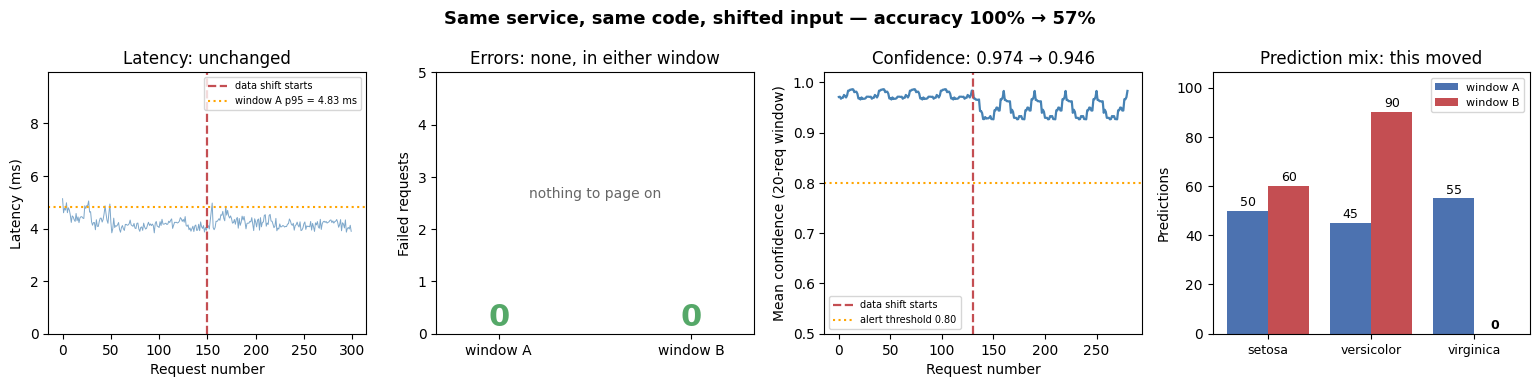

In [8]:
# WHAT: run the SAME deployed model over two windows of real requests — the
# held-out flowers as they are, then the same flowers with the petal measurements
# arriving on a different scale — and record what each dashboard would show.
# WHY: this is the Instacart claim made checkable. Nothing about the service
# changes; only the world does. We measure real latency, real errors, real
# confidence and the real class mix, and see which panel actually moves.
import numpy as np
import time
from collections import Counter

N_PER_WINDOW = 150
idx = np.arange(N_PER_WINDOW) % len(X_test)

# Window A: production traffic that matches training — the real held-out rows.
window_a = X_test[idx]
# Window B: the same flowers, but petal length/width now arrive at 0.62x the old
# scale — a recalibrated instrument, a new supplier's measurements, a unit change.
# The model is untouched and the API is untouched. Only the incoming data moved.
PETAL_SCALE = np.array([1.0, 1.0, 0.62, 0.62])
window_b = X_test[idx] * PETAL_SCALE
truth = y_test[idx]

def serve(batch):
    """One request at a time, exactly as the endpoint would, timing each call."""
    latencies, confidences, predictions, errors = [], [], [], 0
    for row in batch:
        t0 = time.perf_counter()
        try:
            scaled = scaler.transform(row.reshape(1, -1))
            p = int(clf.predict(scaled)[0])
            c = float(clf.predict_proba(scaled)[0].max())
        except Exception:
            errors += 1
            p, c = -1, 0.0
        latencies.append((time.perf_counter() - t0) * 1000)
        predictions.append(p)
        confidences.append(c)
    return np.array(latencies), np.array(confidences), np.array(predictions), errors

lat_a, conf_a, pred_a, err_a = serve(window_a)
lat_b, conf_b, pred_b, err_b = serve(window_b)
acc_a = float((pred_a == truth).mean())
acc_b = float((pred_b == truth).mean())

print(f"{'signal':<34}{'window A (matched)':>20}{'window B (shifted)':>20}")
print('-' * 74)
print(f"{'p50 latency (ms)':<34}{np.percentile(lat_a,50):>20.2f}{np.percentile(lat_b,50):>20.2f}")
print(f"{'p95 latency (ms)':<34}{np.percentile(lat_a,95):>20.2f}{np.percentile(lat_b,95):>20.2f}")
print(f"{'errors':<34}{err_a:>20d}{err_b:>20d}")
print(f"{'mean confidence':<34}{conf_a.mean():>20.3f}{conf_b.mean():>20.3f}")
print(f"{'share predicted virginica':<34}{(pred_a==2).mean():>20.1%}{(pred_b==2).mean():>20.1%}")
print(f"{'ACCURACY (labels, not available live)':<34}{acc_a:>20.3f}{acc_b:>20.3f}")
print()
print(f"p50 latency changed by {100*(np.percentile(lat_b,50)/np.percentile(lat_a,50)-1):+.1f}% "
      f"and p95 by {100*(np.percentile(lat_b,95)/np.percentile(lat_a,95)-1):+.1f}% across the shift.")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.9))
split = N_PER_WINDOW
all_lat = np.concatenate([lat_a, lat_b])
all_conf = np.concatenate([conf_a, conf_b])

ax = axes[0]
ax.plot(all_lat, lw=0.7, color='steelblue', alpha=0.7)
ax.axvline(split, color='#C44E52', ls='--', lw=1.6, label='data shift starts')
ax.axhline(np.percentile(lat_a, 95), color='orange', ls=':', lw=1.5,
           label=f'window A p95 = {np.percentile(lat_a,95):.2f} ms')
ax.set_title('Latency: unchanged')
ax.set_xlabel('Request number'); ax.set_ylabel('Latency (ms)')
ax.set_ylim(0, max(np.percentile(all_lat, 99) * 2, 1))
ax.legend(fontsize=7)

ax = axes[1]
ax.bar(['window A', 'window B'], [err_a, err_b], color='#55A868', width=0.5)
for xi, e in enumerate([err_a, err_b]):
    ax.text(xi, 0.15, str(e), ha='center', fontsize=22, fontweight='bold', color='#55A868')
ax.set_title('Errors: none, in either window')
ax.set_ylabel('Failed requests')
ax.set_ylim(0, 5)
ax.text(0.5, 2.6, 'nothing to page on', ha='center', fontsize=10, color='#666666')

ax = axes[2]
w = 20
roll = np.convolve(all_conf, np.ones(w) / w, mode='valid')
ax.plot(range(len(roll)), roll, color='steelblue', lw=1.6)
ax.axvline(split - w, color='#C44E52', ls='--', lw=1.6, label='data shift starts')
ax.axhline(0.80, color='orange', ls=':', lw=1.5, label='alert threshold 0.80')
ax.set_ylim(0.5, 1.02)
ax.set_title(f'Confidence: {conf_a.mean():.3f} → {conf_b.mean():.3f}')
ax.set_xlabel('Request number'); ax.set_ylabel(f'Mean confidence ({w}-req window)')
ax.legend(fontsize=7)

ax = axes[3]
labels = list(iris.target_names)
counts_a = [int((pred_a == i).sum()) for i in range(3)]
counts_b = [int((pred_b == i).sum()) for i in range(3)]
xpos = np.arange(3)
ax.bar(xpos - 0.2, counts_a, width=0.4, color='#4C72B0', label='window A')
ax.bar(xpos + 0.2, counts_b, width=0.4, color='#C44E52', label='window B')
for xi, (ca, cb) in enumerate(zip(counts_a, counts_b)):
    ax.text(xi - 0.2, ca + 2, str(ca), ha='center', fontsize=9)
    ax.text(xi + 0.2, cb + 2, str(cb), ha='center', fontsize=9,
            fontweight='bold' if cb == 0 else 'normal')
ax.set_ylim(0, max(counts_a + counts_b) * 1.18)
ax.set_xticks(xpos); ax.set_xticklabels(labels, fontsize=9)
ax.set_title('Prediction mix: this moved')
ax.set_ylabel('Predictions')
ax.legend(fontsize=8)

fig.suptitle(f'Same service, same code, shifted input — accuracy {acc_a:.0%} → {acc_b:.0%}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**🔍 Read the figure.** The title carries the outcome: **accuracy fell from 100% to 57%** on the same held-out flowers. Now look at what an infrastructure dashboard would have shown while that happened.

*Panel 1 — latency:* the trace runs straight through the red shift line with no step, and the printed table shows p50 and p95 agreeing across the two windows to within a fraction of a millisecond. The model does exactly the same amount of work on shifted numbers as on normal ones. *Panel 2 — errors:* **zero in both windows.** Every request returned a well-formed prediction with an HTTP 200. There is nothing here to page anyone about. *Panel 3 — confidence:* mean confidence moved from **0.974 to 0.946**, a drop of under three points that never approaches the 0.80 alert threshold. The model is nearly as certain as before and it is wrong about half the time — the miscalibration warned about in "⚠️ Where this breaks", now measured rather than asserted. *Panel 4 — prediction mix:* here is the signal. **Virginica predictions went from 55 to zero**, and versicolor exactly doubled. Nothing about the service moved; the class mix moved completely.

Two conclusions follow, and the second one matters more. First: if you monitor one model signal that is not latency, monitor the prediction distribution — it moved here while confidence barely did. Second: it told you *something changed*, not *what is correct*. The 57% figure is only visible because this is a classroom and we kept the labels. In production those labels arrive late or never, which is precisely why Instacart's response was to retrain hourly on a three-day window rather than to add another chart.

## Summary

**What to log** for every prediction:
- Timestamp, request ID, model version
- Input features (for replay and debugging)
- Prediction and confidence score
- Latency in milliseconds
- Any error message

**Why log input features**: without them you cannot replay a failed request, debug an unexpected prediction, or run distribution shift analysis on the inputs themselves.

**Latency percentiles**:
- p50 = median — most users experience this
- p95 = 95th percentile — 1 in 20 users experiences this or worse
- p99 = 99th percentile — the worst 1% of requests; what your worst-case user sees

**Monitoring without ground truth**: use confidence score distributions and prediction class distributions as proxy signals. A sudden drop in mean confidence or shift in class distribution indicates the model is seeing unfamiliar data and should be investigated.

## Self-Check

1. **What is the difference between p50 and p99 latency?**
   *(Which one matters more for user experience? When would you care about p99?)*

2. **Why is logging the input features (not just the predictions) important?**
   *(Think about what you can do with the logged features that you cannot do with just the prediction.)*

3. **If you don't have ground-truth labels for new data, how can you detect model degradation?**
   *(Name at least two proxy signals shown in this notebook.)*

## ⚠️ Where this breaks

- **The drift test in section 6 compares confidence, not correctness.** A KS statistic of **0.840** with p ≈ 3.8e-72 between the healthy and degraded windows is a genuinely strong signal — but it is a signal that the *model's certainty* changed, not that its *answers* got worse. A miscalibrated model can stay confident while being wrong (see Unit 1, notebook 06, where doubling every feature moved mean confidence by only 0.09).
- **Latency here is simulated, and simulated latency has no tail.** The distribution above was generated with random noise; real production tails come from garbage collection, cold caches, noisy neighbours and retries, and they are far uglier than anything a noise model produces. Use this notebook to learn the *machinery* of percentiles, not to calibrate expectations.
- **Logging every input feature is a cost and a liability.** At 141.8 KB per 500 requests, a service at 100 requests/second writes tens of gigabytes a day, and cloud log ingestion is billed per gigabyte. It is also personal data in many domains. Sample it, redact it, or hash it — and decide that deliberately rather than discovering the bill.
- **The assumption that must hold:** the reference window is a period you actually know was healthy. Every drift comparison in this notebook is against "a known-good period". If the reference window already contained the problem, the test compares bad against bad and reports that all is well.
- **Percentiles do not average, and dashboards will let you average them anyway.** The mean of four hourly p99s is not the daily p99. Aggregating percentiles across time buckets or across instances is a standard, silent error in monitoring dashboards; compute percentiles from the raw distribution over the window you care about.
- **The cheaper alternative.** If your service already emits access logs and you only need availability and latency, the platform's built-in metrics (CloudWatch, Cloud Monitoring, Azure Monitor) give you that for free. Build the structured prediction log when you need the *model* questions answered — replay, drift, per-version comparison — because that is the part no platform provides.

## 🔭 State of the field (2026)

Structured JSON log lines, percentiles computed from the raw distribution, and a confidence proxy compared against a known-good window are still the correct production monitoring stack, and the Instacart test is still the point of it: a perfectly healthy service can serve wrong answers. The 2026 caution is aimed at the drift half. Work accepted to IDA 2026 argues that concept-drift *detection* is ill-posed as it is usually framed — what a detector reports is substantially a product of the window you chose rather than of the data-generating process — and reports that ordinary periodic retraining frequently outperforms drift-aware methods (Gower-Winter et al., 2026). Read that as a reason to benchmark any detector you build against a deliberately boring baseline — retrain on a schedule, which is in fact what Instacart did when it moved to hourly runs and a one-week lookback — not as a reason to stop measuring.

The other change is scope. Where a prediction used to be one log line, a language-model or agent call is a trace of steps, tool calls and costs, and observability work now sets out explicitly what to record at each one (Dong et al., 2024). That is this notebook's log schema applied to a longer unit of work: same discipline, more fields.

- Gower-Winter, B., Groen, M., & Krempl, G. (2026). *The Window Dilemma: Why Concept Drift Detection is Ill-Posed*. <https://arxiv.org/abs/2602.06456>
- Dong, L., Lu, Q., & Zhu, L. (2024). *AgentOps: Enabling Observability of LLM Agents*. <https://arxiv.org/abs/2411.05285>

## 📚 References

1. Breck, E., Cai, S., Nielsen, E., Salib, M., & Sculley, D. (2017). *The ML Test Score: A Rubric for ML Production Readiness and Technical Debt Reduction*. IEEE Big Data. <https://research.google/pubs/the-ml-test-score-a-rubric-for-ml-production-readiness-and-technical-debt-reduction/>
2. Klaise, J., Van Looveren, A., Cox, C., Vacanti, G., & Coca, A. (2020). *Monitoring and Explainability of Models in Production*. ICML Workshop on Challenges in Deploying and Monitoring ML Systems. <https://arxiv.org/abs/2007.06299>
3. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
4. Gower-Winter, B., Groen, M., & Krempl, G. (2026). *The Window Dilemma: Why Concept Drift Detection is Ill-Posed*. International Symposium on Intelligent Data Analysis (IDA) 2026. <https://arxiv.org/abs/2602.06456>
5. Dong, L., Lu, Q., & Zhu, L. (2024). *AgentOps: Enabling Observability of LLM Agents*. arXiv. <https://arxiv.org/abs/2411.05285>
